# Exploration of How Job Access by Transit Relates to Upward Mobility

This workbook assembles and explores neighborhood-level transit job-accessibility data for the Chicago metro, with the goal of creating reproducible insights on how transit access, as measured by UM Accessibility Observatory's Access Across America dataset, relates to upward mobility, as measured by the metrics used in Opportunity Atlas.

We ask whether transit network reach predicts upward mobility beyond neighborhood composition; across specifications the answer is no, a bounded null.

## Contents

- [Exploring transit access data](#Exploring-Transit-Access-Data)
- [Joining transit access to mobility outcomes](#Joining-Transit-Access-to-Mobility-Outcomes)
- [Relating job access to mobility outcomes](#Relating-Job-Access-to-Mobility-Outcomes)
  - [Correlations across travel-time thresholds](#Correlations-Across-Travel-Time-Thresholds)
  - [Controls and feature construction](#Controls-and-Feature-Construction)
  - [Regression specifications](#Regression-Specifications)
- [Limitations and AI use](#Limitations-and-AI-Use)


Begin by running the below cell to import the required packages.

In [1]:
%pip install -r requirements.txt
import pandas as pd
import numpy as np            
import geopandas as gpd        
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy
import statsmodels.formula.api as smf

Note: you may need to restart the kernel to use updated packages.


First, we load the [transit access data](https://conservancy.umn.edu/items/cce7c4c8-8183-4990-b484-1f8199f0f9a6) from Illinois for 2024. 


We choose to use data from a single year rather than pooling across the available data as the available years span three distinct transit regimes: pre-pandemic, pandemic service cuts, and partial recovery. 
2024 is the most recent year available, and since every release comes well after the childhoods we study, we use it as a stand-in for the area's transit system, whose overall layout has changed little. The most important difference between this data and the true data from the 1980s is the distribution of service, not the layout of the network itself. This issue would not be resolved by choosing the earliest available data (2019) or smoothing in any way. 
## Exploring Transit Access Data

In [2]:
illinois_transit = pd.read_csv('Illinois/Illinois_17_transit_census_tract_2024.csv', dtype={'Census ID': str})

Now, we take a quick look at the first 20 rows, since we need to confirm the threshold ranges.

In [3]:
illinois_transit.head(20)

,Mode,Year,State FIPS,State,Summary Level,Census ID,Departure,LTS,Threshold,Weighted_average_total_jobs
0,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,5,82.841256
1,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,10,204.050509
2,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,15,483.799660
3,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,20,1001.448642
4,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,25,1742.258913
5,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,30,2802.909168
6,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,35,3978.956282
7,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,40,5423.247453
8,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,45,7183.747878
9,transit,2024,17,Illinois,census_tract,17001000100,7:00-8:59,NaN,50,9149.042869


Confirming the description from the dataset's documentation, the file is in long format, with one row per census tract per travel-time threshold. Thresholds run from 5 to 60 minutes in 5-minute steps, so each tract appears 12 times, visible above in the repeated `Census ID`. 


The key fields:

- `Census ID`: the 11-digit 2020 census tract GEOID, read as a string to preserve it as an identifier.
- `Threshold`: the maximum travel time in minutes including walk/roll time; the jobs count includes everything reachable within this many minutes.
- `Weighted_average_total_jobs`: the worker-weighted number of jobs reachable from that tract within the threshold, using walk/roll plus public transit during the 7–9am peak. This residence-based measure is the one we build the analysis on. Where a tract has no usable transit service, the value falls back to walk/roll access rather than zero, something to keep in mind as we move forward.

We drop `LTS` (Level of Traffic Stress), which is a bike-network classification that does not apply to transit and is therefore entirely null.

We begin by exploring the data.

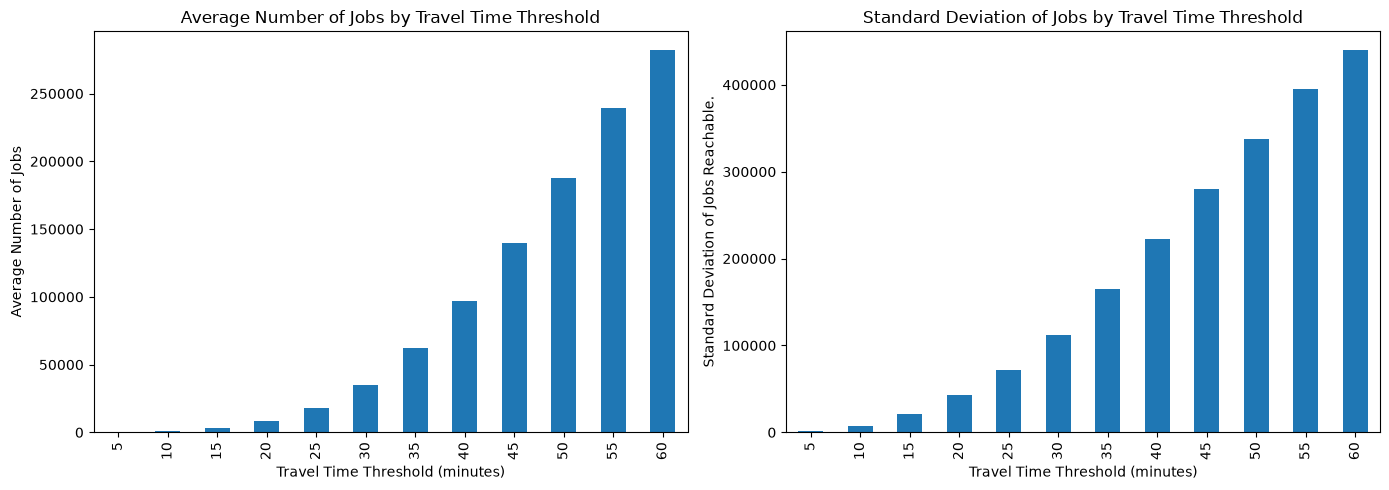

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average jobs reachable per threshold
avg_jobs_by_threshold = illinois_transit.groupby('Threshold')['Weighted_average_total_jobs'].mean()
avg_jobs_by_threshold.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Number of Jobs by Travel Time Threshold')
axes[0].set_xlabel('Travel Time Threshold (minutes)')
axes[0].set_ylabel('Average Number of Jobs')

# Variation in jobs reachable per threshold
variation_by_threshold = illinois_transit.groupby('Threshold')['Weighted_average_total_jobs'].std()
variation_by_threshold.plot(kind='bar', ax=axes[1])
axes[1].set_title('Standard Deviation of Jobs by Travel Time Threshold')
axes[1].set_xlabel('Travel Time Threshold (minutes)')
axes[1].set_ylabel('Standard Deviation of Jobs Reachable.')

plt.tight_layout()
plt.show()

Both the average number of jobs reachable and the standard deviation across tracts increase convexly, as accessible area grows roughly with the square of travel time (doubling the time roughly quadruples the area). This effect is compounded by longer windows reaching dense job centers. Because these variables are measured on different scales, we compare their relative dispersion using the coefficient of variation, which divides each variable’s standard deviation by its mean.

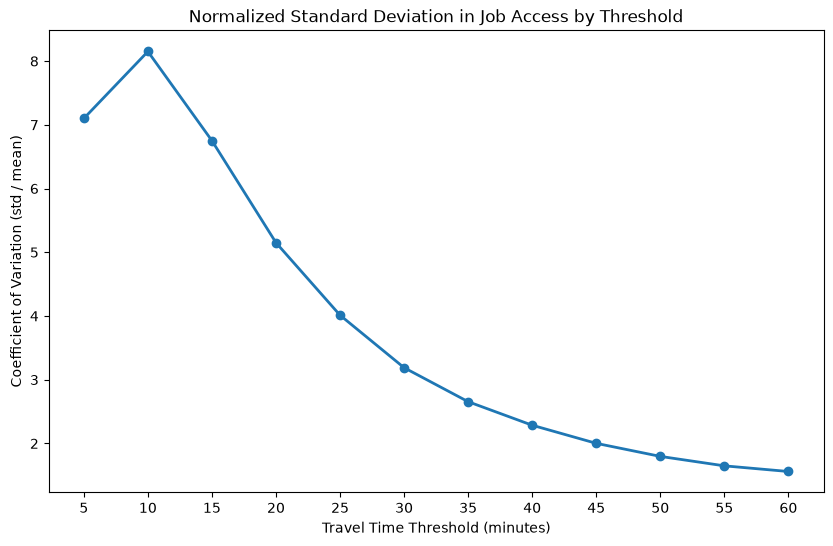

In [5]:
# Remove the scale effect so spread is comparable across thresholds
grp = illinois_transit.groupby('Threshold')['Weighted_average_total_jobs']
cv = grp.std() / grp.mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cv.index, cv.values, marker='o', linewidth=2)
ax.set_xlabel('Travel Time Threshold (minutes)')
ax.set_ylabel('Coefficient of Variation (std / mean)')
ax.set_title('Normalized Standard Deviation in Job Access by Threshold')
ax.set_xticks(cv.index)
plt.show()

By normalizing the standard deviation, we observe that relative variation in accessible jobs peaks at the 10-minute threshold and sharply decreases as we approach an hour. The number of jobs a tract can reach quickly is small and depends on its immediate surroundings, so tracts differ sharply relative to that small average. Longer windows let most tracts reach a large, largely shared pool of jobs, which compresses the relative differences. This is especially true in Illinois, where roughly 70% of the population lives in the Chicago metropolitan area and long windows converge on the same dense job core.

Given the heavy right skew, we examine the distributions on a log scale, where relative differences become comparable across the full range.

In [6]:
jobs_at_10_m = illinois_transit.loc[illinois_transit['Threshold'] == 10, 'Weighted_average_total_jobs']
min(jobs_at_10_m)

0.0

A quick check reveals the minimum weighted average total jobs in a tract is 0, so we have to transform by computing log(Weighted_average_total_jobs + 1) in order to avoid taking log(0), which is undefined.

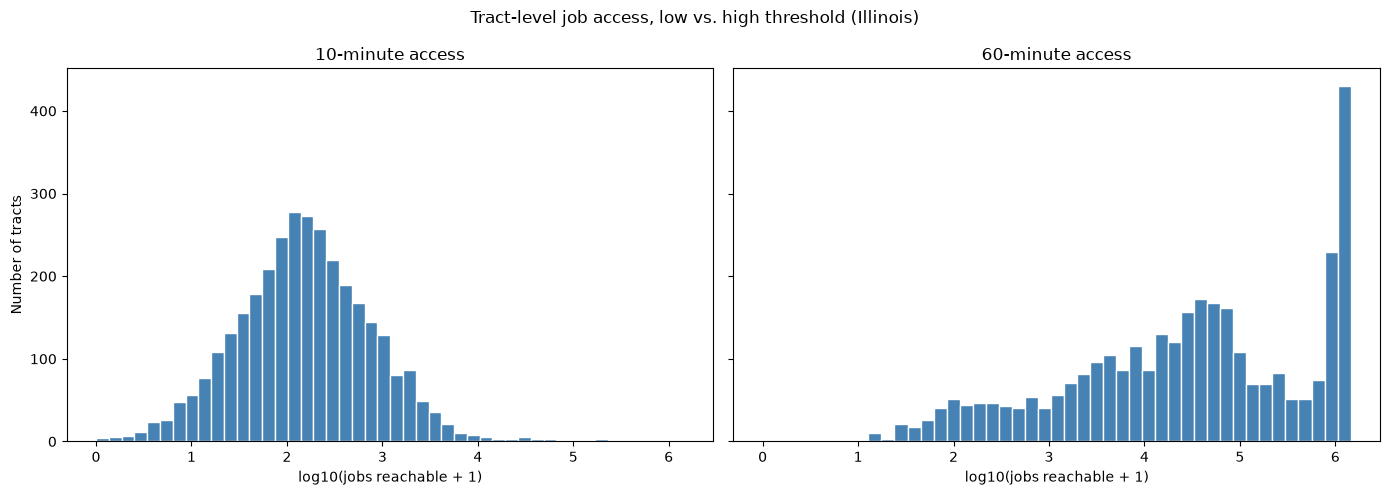

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, thr in zip(axes, [10, 60]):
    jobs = illinois_transit.loc[illinois_transit['Threshold'] == thr, 'Weighted_average_total_jobs']
    ax.hist(np.log10(jobs + 1), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{thr}-minute access')
    ax.set_xlabel('log10(jobs reachable + 1)')

axes[0].set_ylabel('Number of tracts')
fig.suptitle('Tract-level job access, low vs. high threshold (Illinois)')
plt.tight_layout()
plt.show()

In log space:

- The 10-minute distribution is roughly log-normal — the transform absorbs the skew cleanly, so we work with log job access from here on.
- The 60-minute distribution shifts far right and spreads wide, with a spike at the ceiling, where hundreds of tracts reach essentially the entire metro job pool within an hour.

Now, we move to analyzing the Chicago metro, as that is where our research question lives. We take the subset of Illinois that corresponds with the Chicago metro by using the county codes, which are prefixes of the Census ID.

In [8]:
# Cook, DuPage, Kane, Kendall, Lake, McHenry, Will counties
chicago_counties = ['17031', '17043', '17089', '17093', '17097', '17111', '17197']

illinois_transit['county'] = illinois_transit['Census ID'].str[:5]
chicago_transit = illinois_transit[illinois_transit['county'].isin(chicago_counties)].copy()

Having defined the subset of transit access data that corresponds to Chicago, we can repeat the previous analysis.

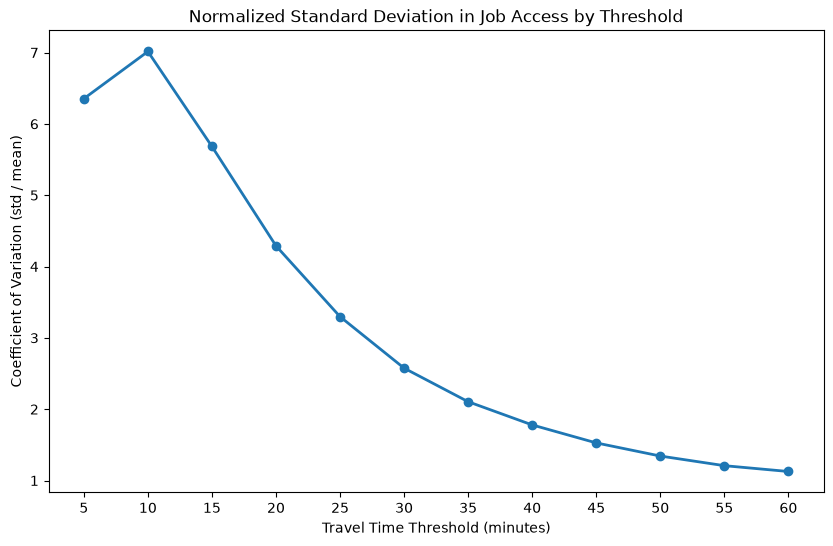

In [9]:
# Remove the scale effect so spread is comparable across thresholds
grp = chicago_transit.groupby('Threshold')['Weighted_average_total_jobs']
cv = grp.std() / grp.mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cv.index, cv.values, marker='o', linewidth=2)
ax.set_xlabel('Travel Time Threshold (minutes)')
ax.set_ylabel('Coefficient of Variation (std / mean)')
ax.set_title('Normalized Standard Deviation in Job Access by Threshold')
ax.set_xticks(cv.index)
plt.show()

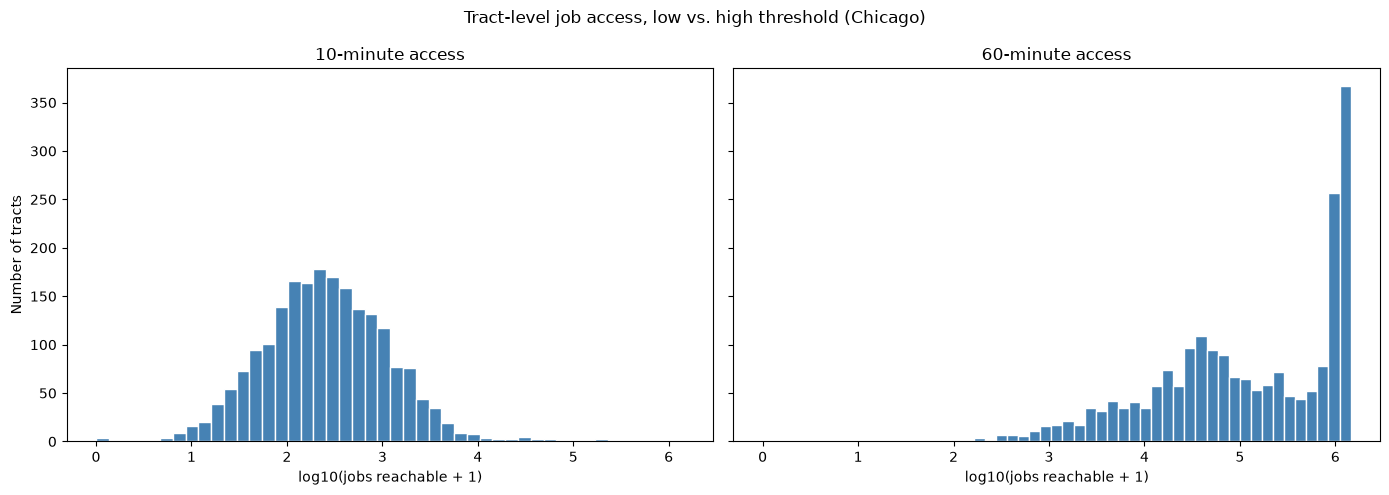

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, thr in zip(axes, [10, 60]):
    jobs = chicago_transit.loc[chicago_transit['Threshold'] == thr, 'Weighted_average_total_jobs']
    ax.hist(np.log10(jobs + 1), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{thr}-minute access')
    ax.set_xlabel('log10(jobs reachable + 1)')

axes[0].set_ylabel('Number of tracts')
fig.suptitle('Tract-level job access, low vs. high threshold (Chicago)')
plt.tight_layout()
plt.show()

The data on reachable jobs in the Chicago area follows a similar distribution as the data for Illinois overall, with a slight shift toward the right. The similarity is sensible given the Chicago metro accounts for ~70% of the total population of Illinois. At this point, we can join it with the Opportunity Atlas data.
## Joining Transit Access to Mobility Outcomes

We begin by loading the tract outcomes dataset from Opportunity Atlas, which is available [here](https://opportunityinsights.org/data/). Note that the site warns against opening this file in spreadsheet software to avoid crashing Excel. Luckily, we are using pandas!

In [11]:
outcomes_data = pd.read_csv('tract_outcomes_early.csv')

/var/folders/hf/_63j7ssn075cgm0zx7brpnd80000gn/T/ipykernel_1751/3331212694.py:1: DtypeWarning: Columns (0: czname) have mixed types. Specify dtype option on import or set low_memory=False.
  outcomes_data = pd.read_csv('tract_outcomes_early.csv')


In [12]:
outcomes_data.shape

(73278, 7897)

As expected from the warning, the outcomes data from Opportunity Insights is massive, both long and wide. The first step is using the codebook to determine how we can join this data with the Chicago transit data. 

In [13]:
outcomes_data.dtypes

state                     int64
county                    int64
tract                     int64
cz                      float64
czname                      str
                         ...   
kii_natam_pooled_p75    float64
kii_natam_male_p25      float64
kii_natam_male_p75      float64
kii_natam_female_p25    float64
kii_natam_female_p75    float64
Length: 7897, dtype: object

In [14]:
outcomes_data[['state','county','tract']].head(5)

,state,county,tract
0,1,1,20100
1,1,1,20200
2,1,1,20300
3,1,1,20400
4,1,1,20500


Analyzing the datatypes and head of the data, we see the pieces needed to reconstruct the GEOID. However they are stored as integers, which strip leading zeros (ex. state 1 should be 01). We can rebuild the 11-digit key by zero-padding state, county, and tract to 2, 3, and 6 digits, then concatenating. We conclude by asserting the result is always 11 characters to check that the reconstruction produced valid key lengths before we join on them. 

In [15]:
cols_to_copy = ['state', 
                'county', 
                'tract', 
                'kfr_pooled_pooled_p25',
                'par_rank_pooled_pooled_mean', 
                'kid_pooled_pooled_n',
                'kid_black_pooled_n']

outcomes = outcomes_data[cols_to_copy].copy()
outcomes['geoid'] = (
    outcomes['state'].astype(str).str.zfill(2)
    + outcomes['county'].astype(str).str.zfill(3)
    + outcomes['tract'].astype(str).str.zfill(6)
)
assert outcomes['geoid'].str.len().eq(11).all()
outcomes[['geoid']]


,geoid
0,01001020100
1,01001020200
2,01001020300
3,01001020400
4,01001020500
...,...
73273,72153750400
73274,72153750501
73275,72153750503
73276,72153750601


Now that we have confirmed that we have reconstructed the GEOIDs, we can proceed toward merging this data with the Chicago transit data.
Before a full merge, we choose a single threshold to join in order to determine how many tracts match.

In [16]:
transit_30 = chicago_transit[chicago_transit['Threshold'] == 30].copy()
assert transit_30['Census ID'].is_unique

merge_check = outcomes.merge(
    transit_30,
    left_on='geoid',
    right_on='Census ID',
    how='outer',
    indicator=True,
)
merge_check['_merge'].value_counts()

_merge
left_only     71382
both           1896
right_only      174
Name: count, dtype: int64

We see that 1,896 Chicago tracts match, 174 transit tracts (~8%) find no Atlas counterpart, and the 71,382 left-only rows are simply the rest of the country. Before proceeding, we investigate the 174 missing tracts.

In [17]:
# 174 transit GEOIDs that didn't match
dropped_geoids = set(merge_check.loc[merge_check['_merge'] == 'right_only', 'Census ID'])

# Look them up in the Atlas file and determine cause for their exclusion
atlas_geoids = set(outcomes['geoid'])

present_but_suppressed = dropped_geoids & atlas_geoids
absent_from_atlas = dropped_geoids - atlas_geoids

print(f"Present in Atlas (NaN): {len(present_but_suppressed)}")
print(f"Absent from Atlas (not in Atlas (2010/2020 vintage mismatch)): {len(absent_from_atlas)}")

Present in Atlas (NaN): 0
Absent from Atlas (not in Atlas (2010/2020 vintage mismatch)): 174


Upon review, the 174 missing tracts are all entirely absent from the Opportunity Atlas data, meaning they were dropped because their GEOID does not exist in the Atlas file instead of existing with a suppressed value. 

This happens because the two datasets use different census vintages. The Atlas is built on 2010 tract definitions while the transit data uses 2020 definitions, and tracts that were split, merged, or renumbered between the two censuses have 2020 GEOIDs with no 2010 counterpart.

We can also look at the geographic distribution of these missing tracts in order to see whether the losses are distributed randomly or concentrated somewhere that could bias the sample.

To map the tracts we need their boundaries, which we can load directly from the Census TIGER/Line 2020 shapefiles, matching the transit data's GEOIDs.

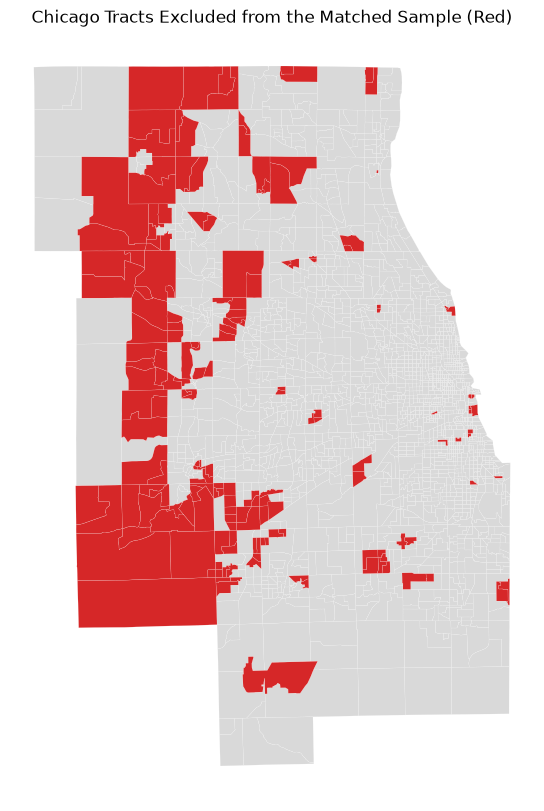

In [18]:
# Load Illinois tract boundaries (2020 vintage)
tiger_url = 'https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_17_tract.zip'
il_tracts = gpd.read_file(tiger_url)

il_tracts = il_tracts[['GEOID','ALAND', 'geometry']].copy()
assert il_tracts['GEOID'].str.len().eq(11).all()

# Flag each Chicago tract as matched or dropped
chi_geoids = set(transit_30['Census ID'])
dropped_geoids = set(merge_check.loc[merge_check['_merge'] == 'right_only', 'Census ID'])

chi_map = il_tracts[il_tracts['GEOID'].isin(chi_geoids)].copy()
chi_map['status'] = np.where(chi_map['GEOID'].isin(dropped_geoids), 'dropped', 'matched')

# Plot dropped tracts on top of the matched base so they stand out
fig, ax = plt.subplots(figsize=(10, 10))
chi_map[chi_map['status'] == 'matched'].plot(ax=ax, color='#d9d9d9', edgecolor='white', linewidth=0.1)
chi_map[chi_map['status'] == 'dropped'].plot(ax=ax, color='#d62728', edgecolor='white', linewidth=0.1)
ax.set_title('Chicago Tracts Excluded from the Matched Sample (Red)')
ax.axis('off')
plt.show()

The overwhelming majority of dropped tracts sit on the periphery of the Chicago metro, so our estimates best describe the transit-served portion of the metro. This is the region where our question has the most relevance, but the loss is non-random and worth keeping in mind as a limitation. Finally, we can move toward analyzing the relationship between transit access and our outcome variable.

## Relating Job Access to Mobility Outcomes

Our outcome variable is `kfr_pooled_pooled_p25`: the mean percentile rank in the national household income distribution for children whose parents were at the 25th percentile, pooled across race and gender. This is the Opportunity Atlas's standard measure of upward mobility for children from low-income families.

We build the working sample, consisting of matched tracts with a non-missing outcome and keeping the full threshold curve for each tract.

In [19]:
OUTCOME = 'kfr_pooled_pooled_p25'

# All thresholds, only matched tracts with a usable outcome
transit_mobility = chicago_transit.merge(
    outcomes[['geoid', OUTCOME]],
    left_on='Census ID',
    right_on='geoid',
    how='inner',
)
transit_mobility = transit_mobility[transit_mobility[OUTCOME].notna()].copy()
transit_mobility['log_jobs'] = np.log10(transit_mobility['Weighted_average_total_jobs'] + 1)

n_tracts = transit_mobility['Census ID'].nunique()
print(f"usable tracts: {n_tracts}")
assert transit_mobility.groupby('Threshold')['Census ID'].nunique().eq(n_tracts).all()

usable tracts: 1893


### Correlations Across Travel-Time Thresholds

We can now examine how the access–mobility correlation varies across thresholds.

 If low thresholds mostly reflect local surroundings while high thresholds capture what the transit network connects a tract to, the relationship should strengthen in magnitude as the window widens. 
 
 We compute both Pearson and Spearman correlations: Pearson captures the linear relationship in levels, while Spearman reduces sensitivity to extreme tracts by comparing ranked values.

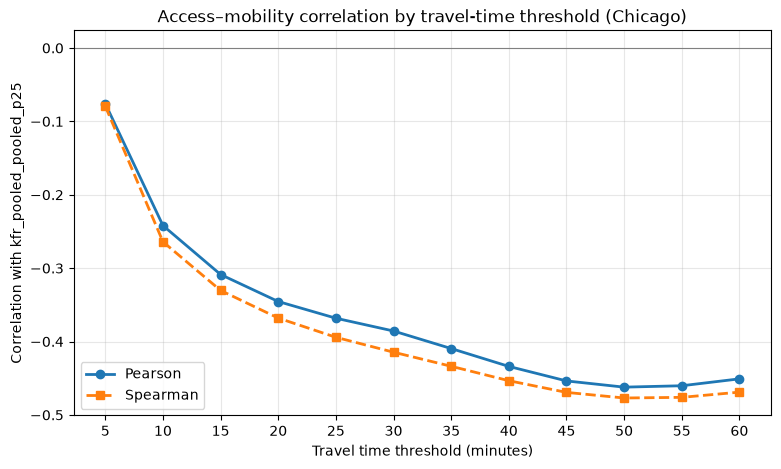

Threshold
5    -0.076
10   -0.242
15   -0.309
20   -0.345
25   -0.368
30   -0.386
35   -0.410
40   -0.434
45   -0.454
50   -0.462
55   -0.460
60   -0.451
dtype: float64

In [20]:
corr_by_threshold = (
    transit_mobility.groupby('Threshold')
    .apply(lambda g: g['log_jobs'].corr(g[OUTCOME]), include_groups=False)
)
corr_by_threshold_rank = (
    transit_mobility.groupby('Threshold')
    .apply(lambda g: g['log_jobs'].corr(g[OUTCOME], method='spearman'), include_groups=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(corr_by_threshold.index, corr_by_threshold.values,
        marker='o', linewidth=2, label='Pearson')
ax.plot(corr_by_threshold_rank.index, corr_by_threshold_rank.values,
        marker='s', linewidth=2, linestyle='--', label='Spearman')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Travel time threshold (minutes)')
ax.set_ylabel(f'Correlation with {OUTCOME}')
ax.set_title('Access–mobility correlation by travel-time threshold (Chicago)')
ax.set_xticks(corr_by_threshold.index)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

corr_by_threshold.round(3)

As expected, the correlation strengthens in magnitude as the threshold increases, but the sign is negative. 

This becomes clearer given Chicago's socioeconomic geography: the tracts with the greatest network reach are in and around the core of the city, which includes many of the metro's poorest neighborhoods.

 Meanwhile much of the metro's periphery, where transit reaches far fewer jobs, includes many of Chicago's affluent commuter suburbs. At longer windows this core–periphery contrast dominates, pulling the correlation further negative.

 At this point we reshape from long to wide in order to get one row per tract and have thresholds as columns. This lets us define the transit added access measure: the log-scale gap between 60- and 10-minute access, in order to capture what the network reaches beyond a tract's immediate surroundings.

In [21]:
# Pivot to one row per tract, thresholds as columns (log_jobs_5 ... log_jobs_60)
wide = transit_mobility.pivot_table(index='Census ID', columns='Threshold', values='log_jobs')
wide.columns = [f'log_jobs_{c}' for c in wide.columns]

# Re-attach the outcome (constant across a tract's 12 threshold rows)
tract_level = wide.merge(
    transit_mobility[['Census ID', OUTCOME]].drop_duplicates('Census ID'),
    on='Census ID',
)

# Define network reach beyond a tract's immediate surroundings
tract_level['transit_added'] = tract_level['log_jobs_60'] - tract_level['log_jobs_10']
assert tract_level['Census ID'].is_unique

# Calc correlations
tract_level[['log_jobs_10', 'log_jobs_60', 'transit_added', OUTCOME]].corr().round(3)

,log_jobs_10,log_jobs_60,transit_added,kfr_pooled_pooled_p25
log_jobs_10,1.000,0.750,0.054,-0.242
log_jobs_60,0.750,1.000,0.701,-0.451
transit_added,0.054,0.701,1.000,-0.420
kfr_pooled_pooled_p25,-0.242,-0.451,-0.420,1.000


Transit added access is nearly orthogonal to local access with correlation = 0.05 yet correlates with mobility at −0.42. The network dimension is a distinct variable, carrying nearly as strong a negative relationship as raw access (within the 60 minute threshold). 

There is no clear mechanism by which transit access itself lowers children's mobility, so the negative sign likely reflects who lives in well-connected tracts rather than any effect of transit itself. To separate the two, we turn to controls. 

### Controls and Feature Construction
As we begin to add controls, we draw on variables that describe who lives in each tract. We will use mean parent income rank and child counts by race from the Atlas file, as well as land area from TIGER to construct a density measure.

In [22]:
controls_cols = [
    'geoid',
    'par_rank_pooled_pooled_mean',
    'kid_pooled_pooled_n',
    'kid_black_pooled_n',
]

# Merge Opportunity Atlas controls
reg = tract_level.merge(
    outcomes[controls_cols],
    left_on='Census ID',
    right_on='geoid',
    how='left',
    validate='one_to_one',
)

# Land area from TIGER for density (ALAND is square meters)
SQ_METERS_PER_SQ_MILE = 2589988.110336
tract_area = il_tracts[['GEOID', 'ALAND']].copy()
tract_area['land_sq_miles'] = tract_area['ALAND'] / SQ_METERS_PER_SQ_MILE

reg = reg.merge(
    tract_area[['GEOID', 'land_sq_miles']],
    left_on='Census ID',
    right_on='GEOID',
    how='left',
    validate='one_to_one',
)

# Regression features
reg['frac_black']  = reg['kid_black_pooled_n'] / reg['kid_pooled_pooled_n']
reg['log_density'] = np.log10(reg['kid_pooled_pooled_n'] / reg['land_sq_miles'] + 1)
reg['county']      = reg['Census ID'].str[:5]

regression_cols = [
    'Census ID',
    'kfr_pooled_pooled_p25',
    'log_jobs_10',
    'log_jobs_60',
    'transit_added',
    'par_rank_pooled_pooled_mean',
    'frac_black',
    'log_density',
    'county',
]

# Remove invalid ratios, infinite logs, and incomplete observations
reg = (
    reg.replace([np.inf, -np.inf], np.nan)
       .dropna(subset=regression_cols)
       .loc[:, regression_cols]
       .reset_index(drop=True)
)

print(f"regression sample: {len(reg)} tracts")
reg.head()

regression sample: 1892 tracts


,Census ID,kfr_pooled_pooled_p25,log_jobs_10,log_jobs_60,transit_added,par_rank_pooled_pooled_mean,frac_black,log_density,county
0,17031010100,0.347873,2.806478,6.008903,3.202425,0.273675,0.683376,4.031670,17031
1,17031010201,0.345799,2.802381,5.929961,3.127580,0.317652,0.400270,4.057054,17031
2,17031010202,0.342500,3.191729,6.057697,2.865969,0.387310,0.401031,3.854510,17031
3,17031010300,0.345532,3.058226,6.026399,2.968173,0.371488,0.445040,3.787777,17031
4,17031010400,0.448764,3.463362,6.038052,2.574690,0.320996,0.210280,3.481593,17031


### Regression Specifications

Having constructed our feature space, we now move to modeling with controls. 

We proceed through nested specifications, fitting the same regression with control blocks added one at a time. We begin with access alone, then add parent income, then racial composition and density, then county fixed effects, watching how the access coefficient moves. We run this ladder twice, once for total 60-minute access and once for transit added access, to see whether the two components respond differently to the same controls.

In [23]:
specs = {
    '1. bivariate':       'kfr_pooled_pooled_p25 ~ {var}',
    '2. + parent income': 'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean',
    '3. + race, density': 'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean'
                          ' + frac_black + log_density',
    '4. + county FE':     'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean'
                          ' + frac_black + log_density + C(county)',
}

def run_ladder(var):
    """Fit the nested specs for one access measure; report its coefficient."""
    rows = []
    for name, template in specs.items():
        m = smf.ols(template.format(var=var), data=reg).fit(cov_type='HC3')  # robust SEs
        rows.append({
            'spec': name,
            'coef': m.params[var],
            'se':   m.bse[var],
            't':    m.tvalues[var],
            'R2':   m.rsquared,
            'n':    int(m.nobs),
        })
    return pd.DataFrame(rows).set_index('spec').round(4)

ladder_60    = run_ladder('log_jobs_60')
ladder_added = run_ladder('transit_added')

comparison = pd.concat(
    {'log_jobs_60': ladder_60[['coef', 'se', 't']],
     'transit_added': ladder_added[['coef', 'se', 't']]},
    axis=1,
)
comparison

log_jobs_60                  transit_added                 
                          coef      se        t          coef      se        t
spec                                                                          
1. bivariate           -0.0464  0.0020 -22.8550       -0.0655  0.0036 -18.2782
2. + parent income      0.0010  0.0024   0.4155       -0.0028  0.0031  -0.9191
3. + race, density     -0.0047  0.0027  -1.6971        0.0135  0.0031   4.4348
4. + county FE         -0.0179  0.0031  -5.7227        0.0088  0.0035   2.5387

Total 60-minute access and transit added access are mechanically related because transit added access is defined as the difference between 60- and 10-minute log job access. When estimated separately, each coefficient may partly absorb variation associated with the omitted component. This helps explain why they diverge under full controls: total access becomes negative, while transit added access becomes positive and statistically significant. We therefore include both components in the same regression to separate their associations with mobility.

In [ ]:
# Decomposition: log_jobs_60 ≡ log_jobs_10 + transit_added, so decompose
decomp = smf.ols(
    'kfr_pooled_pooled_p25 ~ log_jobs_10 + transit_added'
    ' + par_rank_pooled_pooled_mean + frac_black + log_density + C(county)',
    data=reg,
).fit(cov_type='HC3')

final_table = pd.DataFrame({
    'coefficient': decomp.params,
    'robust_se':   decomp.bse,
    'ci_lower':    decomp.conf_int()[0],
    'ci_upper':    decomp.conf_int()[1],
}).drop(index=[i for i in decomp.params.index if i.startswith('C(county)')]).round(4)

# Standardized effect size for the memo: outcome ranks per 1 SD of network reach
sd_added = reg['transit_added'].std()
print(f"\ntransit_added SD: {sd_added:.3f}")
print(f"1-SD increase in network reach ≈ {decomp.params['transit_added'] * sd_added * 100:.2f} "
      f"percentile ranks of adult income (p25 children)")

ci = decomp.conf_int().loc['transit_added'] * sd_added * 100
print(f"95% CI: [{ci[0]:.2f}, {ci[1]:.2f}] percentile ranks per SD")
final_table


transit_added SD: 0.575
1-SD increase in network reach ≈ -0.30 percentile ranks of adult income (p25 children)
95% CI: [-0.68, 0.08] percentile ranks per SD


,coefficient,robust_se,ci_lower,ci_upper
Intercept,0.4037,0.0226,0.3593,0.4481
log_jobs_10,-0.0237,0.0035,-0.0307,-0.0168
transit_added,-0.0053,0.0034,-0.0119,0.0013
par_rank_pooled_pooled_mean,0.2158,0.0139,0.1885,0.2431
frac_black,-0.1343,0.0038,-0.1419,-0.1268
log_density,0.0056,0.0047,-0.0035,0.0148


The decomposition changes the conclusion from the ladders, and it is the specification to examine, since entering the components separately stops forcing two different quantities to share one coefficient.

Local 10-minute access remains negative and statistically significant, but its interpretation is ambiguous: low nearby employment characterizes both disadvantaged urban tracts and affluent commuter suburbs that are, by design, jobs-sparse near home.

Transit added access, however, is not statistically distinguishable from zero. The positive coefficient in the ladder was an artifact of omitting local access, with which transit added access is negatively related by construction. The interval is tight: a one-standard-deviation change in transit added access moves mobility by at most about 0.7 income-rank percentiles, giving us an informative null.

The dominant variable throughout is racial composition. In Chicago, the geography of transit and the geography of race and income are so deeply entangled that once family income and racial composition are held fixed, transit added access adds essentially no further information about children's mobility prospects. 

In the end, the transit access gradient is real but not explanatory. It reflects who lives near transit rather than any causal effect on upward mobility, consistent with the broader Opportunity Atlas lesson that place-based mobility patterns are deeply tied to neighborhood composition.

## Limitations and AI Use

There are a few limitations to discuss with respect to the data. Most notably, we used a 2024 transit dataset with 2020 census tracts, whereas the Opportunity Atlas measures the mobility of children who grew up decades earlier on 2010 tracts. Ideally we would measure the transit environment those children actually experienced, but no such data exists, so we treat the modern network as a proxy for a layout that has changed little. This misalignment mainly affects the level of service, not the structure of the network, and would not be resolved by any other available year.

The 2020 vintage also introduced a join problem: tracts that were split, merged, or renumbered between 2010 and 2020 have no Atlas counterpart, costing us about 8% of Chicago tracts. This loss was not random, concentrating on the metro's periphery, so our estimates best describe the transit-served core. Because census tracts are drawn to hold roughly equal populations, the tract share lost approximates the population share. 

Finally, our result is descriptive, not causal. We show that transit reach adds no detectable information about mobility beyond neighborhood composition, but composition itself may partly reflect transit's long-run influence on who could afford to live where. We therefore read this as a bounded null: transit reach adds nothing once we compare similar neighborhoods today, which is not evidence that transit never mattered.

As for AI use, the majority of this file was written by hand. 
I used ChatGPT to help me identify candidate datasets for the analysis, as well as to verify my design for the nested OLS strategy. The link to the chat transcript can be found [here](https://chatgpt.com/share/6a5a3697-f520-83ea-9823-9958fd203228). 

I used Codex to design and deploy the website, as front end design is beyond my area of expertise. 

## Appendix: Crosswalk Sensitivity

**The following section was completed entirely by Codex after the original analysis at the direction of the author. It therefore serves only as a sanity check rather than real commentary owned by the author.**

The earlier merge check showed that 174 Chicago-area transit tracts did not match directly to the Opportunity Atlas tract file. These misses arise from the use of different tract vintages: the transit data uses 2020 tract definitions, while the Atlas tract outcomes use 2010 definitions.

To evaluate whether this boundary mismatch affects the regression results, I rerun the same OLS specifications on two samples.

- **Direct exact-GEOID sample:** the original sample that keeps only tract IDs with exact matches.
- **Crosswalked full sample:** the 2020 transit geography after reweighting 2010 Opportunity Atlas outcomes onto 2020 tract boundaries.

Count variables are allocated from 2010 tracts into overlapping 2020 tracts by overlap-area share. Outcome variables are averaged into 2020 tracts using the allocated child sample as weights. For the few tracts with no usable Atlas child sample after crosswalking, nearby same-county tracts provide a spatial fallback so the full transit geography can be retained.


In [51]:
import pandas as pd
import numpy as np
import geopandas as gpd
import statsmodels.formula.api as smf

from pathlib import Path

def find_data_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'Illinois' / 'Illinois_17_transit_census_tract_2024.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find the Illinois transit source folder.')

def find_site_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'data' / 'source' / 'tract_metrics.csv').exists():
            return candidate
    for candidate in candidates:
        nested = candidate / 'chicago-mobility-atlas'
        if (nested / 'data' / 'source' / 'tract_metrics.csv').exists():
            return nested
    raise FileNotFoundError('Could not find the site data/source folder.')

data_root = find_data_root()
site_root = find_site_root()

chicago_counties = ['17031', '17043', '17089', '17093', '17097', '17111', '17197']

transit = pd.read_csv(
    data_root / 'Illinois' / 'Illinois_17_transit_census_tract_2024.csv',
    dtype={'Census ID': str},
)
transit['county'] = transit['Census ID'].str[:5]
chicago_transit_app = transit[transit['county'].isin(chicago_counties)].copy()
chicago_transit_app['log_jobs'] = np.log10(chicago_transit_app['Weighted_average_total_jobs'] + 1)

wide_app = chicago_transit_app.pivot_table(
    index='Census ID',
    columns='Threshold',
    values='log_jobs',
)
wide_app.columns = [f'log_jobs_{c}' for c in wide_app.columns]
wide_app = wide_app.reset_index()
wide_app['transit_added'] = wide_app['log_jobs_60'] - wide_app['log_jobs_10']

outcomes_app = pd.read_csv(
    site_root / 'data' / 'source' / 'opportunity_atlas_chicago.csv',
    dtype={'geoid': str},
)

tracts_app = gpd.read_file(data_root / 'tl_2020_17_tract.zip')[['GEOID', 'ALAND']]
tracts_app = tracts_app[tracts_app['GEOID'].str[:5].isin(chicago_counties)].copy()
tracts_app['land_sq_miles'] = tracts_app['ALAND'] / 2589988.110336

direct_reg = wide_app.merge(
    outcomes_app[[
        'geoid',
        'kfr_pooled_pooled_p25',
        'par_rank_pooled_pooled_mean',
        'kid_pooled_pooled_n',
        'kid_black_pooled_n',
    ]],
    left_on='Census ID',
    right_on='geoid',
    how='left',
    validate='one_to_one',
)
direct_reg = direct_reg.merge(
    tracts_app[['GEOID', 'land_sq_miles']],
    left_on='Census ID',
    right_on='GEOID',
    how='left',
    validate='one_to_one',
)
direct_reg['frac_black'] = direct_reg['kid_black_pooled_n'] / direct_reg['kid_pooled_pooled_n']
direct_reg['log_density'] = np.log10(direct_reg['kid_pooled_pooled_n'] / direct_reg['land_sq_miles'] + 1)
direct_reg['county'] = direct_reg['Census ID'].str[:5]

regression_cols_app = [
    'Census ID',
    'kfr_pooled_pooled_p25',
    'log_jobs_10',
    'log_jobs_60',
    'transit_added',
    'par_rank_pooled_pooled_mean',
    'frac_black',
    'log_density',
    'county',
]
direct_reg = (
    direct_reg.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=regression_cols_app)
    .loc[:, regression_cols_app]
    .reset_index(drop=True)
)

# The prepared crosswalked metrics are generated by scripts/prepare_data.py.
# They keep the transit geography and place Atlas estimates on 2020 tracts.
crosswalk_metrics = pd.read_csv(site_root / 'data' / 'source' / 'tract_metrics.csv', dtype={'geoid': str})
crosswalk_reg = pd.DataFrame({
    'Census ID': crosswalk_metrics['geoid'],
    'kfr_pooled_pooled_p25': crosswalk_metrics['mobility'] / 100,
    'log_jobs_10': np.log10(crosswalk_metrics['jobs_10'] + 1),
    'log_jobs_60': np.log10(crosswalk_metrics['jobs_60'] + 1),
    'transit_added': crosswalk_metrics['transit_added'],
    'par_rank_pooled_pooled_mean': crosswalk_metrics['parent_rank'] / 100,
    'frac_black': crosswalk_metrics['frac_black'],
    'log_density': np.log10(crosswalk_metrics['density'] + 1),
    'county': crosswalk_metrics['geoid'].str[:5],
})
crosswalk_reg = (
    crosswalk_reg.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=regression_cols_app)
    .reset_index(drop=True)
)

print(f"Direct exact-GEOID regression sample: {len(direct_reg):,} tracts")
print(f"Crosswalked full regression sample: {len(crosswalk_reg):,} tracts")
print(f"Additional observations retained: {len(crosswalk_reg) - len(direct_reg):,} tracts")


Direct exact-GEOID regression sample: 1,892 tracts
Crosswalked full regression sample: 2,070 tracts
Additional observations retained: 178 tracts


In [52]:
specs_app = {
    '1. bivariate':       'kfr_pooled_pooled_p25 ~ {var}',
    '2. + parent income': 'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean',
    '3. + race, density': 'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean'
                          ' + frac_black + log_density',
    '4. + county FE':     'kfr_pooled_pooled_p25 ~ {var} + par_rank_pooled_pooled_mean'
                          ' + frac_black + log_density + C(county)',
}

def run_ladder_app(data, var):
    rows = []
    for name, template in specs_app.items():
        model = smf.ols(template.format(var=var), data=data).fit(cov_type='HC3')
        rows.append({
            'spec': name,
            'coef': model.params[var] * 100,
            'se': model.bse[var] * 100,
            't': model.tvalues[var],
            'R2': model.rsquared,
            'n': int(model.nobs),
        })
    return pd.DataFrame(rows)

ladder_sensitivity = pd.concat(
    [
        run_ladder_app(direct_reg, 'log_jobs_60').assign(sample='Direct exact-GEOID', access_var='log_jobs_60'),
        run_ladder_app(direct_reg, 'transit_added').assign(sample='Direct exact-GEOID', access_var='transit_added'),
        run_ladder_app(crosswalk_reg, 'log_jobs_60').assign(sample='Crosswalked full', access_var='log_jobs_60'),
        run_ladder_app(crosswalk_reg, 'transit_added').assign(sample='Crosswalked full', access_var='transit_added'),
    ],
    ignore_index=True,
)

ladder_sensitivity.loc[ladder_sensitivity['spec'].eq('4. + county FE'),
                       ['sample', 'access_var', 'coef', 'se', 't', 'R2', 'n']].round(3)


,sample,access_var,coef,se,t,R2,n
3,Direct exact-GEOID,log_jobs_60,-1.790,0.313,-5.723,0.731,1892
7,Direct exact-GEOID,transit_added,0.881,0.347,2.539,0.725,1892
11,Crosswalked full,log_jobs_60,-1.564,0.281,-5.571,0.729,2070
15,Crosswalked full,transit_added,0.864,0.306,2.824,0.723,2070


The single-variable ladder behaves almost exactly as before. In the fully controlled ladder, `transit_added` remains positive when entered without local 10-minute access. That was already the reason to prefer the decomposition: `transit_added` and local access are mechanically related, so omitting one can push the other around.


In [53]:
def run_decomposition_app(data, label):
    model = smf.ols(
        'kfr_pooled_pooled_p25 ~ log_jobs_10 + transit_added'
        ' + par_rank_pooled_pooled_mean + frac_black + log_density + C(county)',
        data=data,
    ).fit(cov_type='HC3')
    rows = []
    for term in ['log_jobs_10', 'transit_added', 'par_rank_pooled_pooled_mean', 'frac_black', 'log_density']:
        ci = model.conf_int().loc[term]
        rows.append({
            'sample': label,
            'term': term,
            'coef': model.params[term] * 100,
            'se': model.bse[term] * 100,
            'ci_lower': ci[0] * 100,
            'ci_upper': ci[1] * 100,
            'R2': model.rsquared,
            'n': int(model.nobs),
        })
    return pd.DataFrame(rows)

decomposition_sensitivity = pd.concat(
    [
        run_decomposition_app(direct_reg, 'Direct exact-GEOID'),
        run_decomposition_app(crosswalk_reg, 'Crosswalked full'),
    ],
    ignore_index=True,
)

decomposition_sensitivity.loc[
    decomposition_sensitivity['term'].isin(['log_jobs_10', 'transit_added']),
    ['sample', 'term', 'coef', 'se', 'ci_lower', 'ci_upper', 'R2', 'n'],
].round(3)


,sample,term,coef,se,ci_lower,ci_upper,R2,n
0,Direct exact-GEOID,log_jobs_10,-2.374,0.354,-3.068,-1.680,0.737,1892
1,Direct exact-GEOID,transit_added,-0.529,0.337,-1.188,0.131,0.737,1892
5,Crosswalked full,log_jobs_10,-2.074,0.316,-2.694,-1.454,0.734,2070
6,Crosswalked full,transit_added,-0.387,0.302,-0.978,0.205,0.734,2070


The crosswalk does **not** change the substantive result. It increases the regression sample from 1,892 to 2,070 tracts, but the preferred decomposition still estimates `transit_added` near zero with a confidence interval that crosses zero. The coefficient moves from -0.53 to -0.39 income-rank percentile points per log-point of added network reach, and both intervals remain centered around a small effect.

The tract-vintage mismatch therefore affects sample coverage more than interpretation. The crosswalk is preferable because it retains the full 2020 transit geography, but the main finding is unchanged: once neighborhood composition is held constant, added transit reach does not provide detectable explanatory power for upward mobility.
